<a href="https://colab.research.google.com/github/PaoSala/InvestigacionAddiccionTelefonoMdD/blob/main/proyecto_Entrega_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Base - Evaluación de Minería de Datos

## Información del Grupo

- **Nombre o Número de Grupo:**
- **Sección: 001D**
- **Fecha de Entrega:** 1/7/2026

---

## Integrantes del Grupo (máximo 3 estudiantes)

### Estudiante 1
- **Nombre: José**
- **Apellido: Muñoz**
- **Correo institucional: jos.munozh@Duocuc.cl**

### Estudiante 2
- **Nombre: Paolo**
- **Apellido: Sala**
- **Correo institucional: pa.sala@duocuc.cl**


## Tema del Proyecto
Describa el fenómeno o problema a estudiar. Sea específico respecto al objetivo de análisis o predicción.



# **Addicción de uso de Smartphone**

---

## Descripción del Proyecto
Explique el contexto del problema, los actores involucrados y el propósito del análisis. ¿Para qué y para quién serviría este modelo?

El contexto del problema es que se condujo un analisis de como las personas eran addictas por utilizar el celular. Debido a esto, se tuvo que ver los niveles de stress, la cantidad de tiempo que utilizaban el telefono para jugar juegos, ver redes sociales pero tambien viendo en cuanto tiempo uno tenia para dormir, los niveles de stress, si es que afectaba el trabajo o estudios y finalmente ver si el usuario estaba clasificado como addicto al telefono o no.
---

## Introducción a la Metodología

Este documento sigue la estructura de la metodología **CRISP-DM** (*Cross Industry Standard Process for Data Mining*), utilizada ampliamente para abordar proyectos de ciencia de datos y machine learning. Se compone de seis fases fundamentales:

---

## Fases de CRISP-DM

### 1. Comprensión del Negocio
Objetivo del proyecto: El objetivo es analizar y predecir el nivel de riesgo de adicción a los smartphones en los usuarios a partir de sus hábitos de uso diario, patrones de sueño e impactos psicológicos/académicos. Desde una perspectiva social, busca identificar tempranamente comportamientos digitales nocivos.


Decisión que se espera mejorar: Permitir a instituciones educativas o de salud tomar decisiones preventivas y diseñar campañas de concientización focalizadas. El modelo ayuda a clasificar de forma automatizada qué perfiles de usuarios necesitan alertas o intervenciones antes de desarrollar problemas severos de salud mental o caídas críticas en el rendimiento académico.



---

### 2. Comprensión de los Datos
Fuente del dataset: Datos secundarios obtenidos de la plataforma Kaggle, específicamente el dataset "Smartphone Addiction Prediction Data".

Número de registros y columnas: El dataset cuenta con 7,500 registros (filas) y 13 columnas en total (incluyendo identificadores).

Variables objetivo y predictoras:

    Variable Objetivo: addicted_label (Clasificación binaria: 0 para No Adicto, 1 para Adicto).

    Variables Predictoras (X): daily_screen_time_hours, weekend_screen_time, social_media_hours, gaming_hours, notifications_count, apps_installed, sleep_duration_hours, gender, stress_level, y academic_work_impact.

Tipos de datos: * Numéricos Continuos/Discretos: Horas de pantalla, notificaciones, aplicaciones instaladas y horas de sueño.

    Categóricos: gender (Male/Female), stress_level (Low/Moderate/High), academic_work_impact (Low/Moderate/High) y addiction_level.

    Identificadores: transaction_id y user_id (que deben ser descartados para el modelado).
---

### 3. Preparación de los Datos

a. Limpieza de Datos:

    Valores nulos: Se identificaron 819 valores nulos en la columna addiction_level. Al cruzarlos con la variable objetivo, se descubrió que corresponden exactamente a usuarios con addicted_label = 0 (No adictos). Como solución práctica para mantener la consistencia del negocio, se imputaron reemplazándolos por la categoría 'Low'.

    Duplicados y Errores: Revisión de unicidad mediante los IDs para asegurar que no existieran registros repetidos que sesgaran las frecuencias.

b. Transformaciones y Encoding:

    Selección de características: Se eliminan transaction_id y user_id porque no aportan valor predictivo (son correlativos). También se excluye addiction_level para evitar el "data leakage" (fuga de datos), ya que está directamente amarrada a la variable objetivo.

    Codificación: Dado que los algoritmos de Machine Learning (como Scikit-Learn) solo procesan números, se aplica One-Hot Encoding (pd.get_dummies(..., drop_first=True)) a las variables cualitativas (gender, stress_level, academic_work_impact), transformándolas en columnas binarias (0 o 1).


### 4. Análisis Exploratorio de Datos

Estadísticas descriptivas y tendencias: El dataset presenta una distribución de clases de la variable objetivo con una tendencia marcada en el ambiente muestral hacia la adicción (5,308 adictos frente a 2,192 no adictos).

Tendencias observadas (Sus hallazgos clave):

    Incremento en fin de semana: Existe una altísima correlación lineal (0.96) entre las horas en días de semana y los fines de semana; el tiempo de exposición aumenta exponencialmente los sábados y domingos.

    Relación con la adicción: El tiempo diario en pantalla muestra una correlación de 0.58 con la etiqueta de adicto, confirmando de manera empírica que a mayor tiempo de uso, la probabilidad de caer en rangos "Moderate" o "Severe" de adicción se dispara.

Visualizaciones: Se generaron histogramas (sns.histplot) para las 9 variables numéricas, permitiendo verificar visualmente cómo se distribuyen simétricamente los datos de hábitos de vida de los usuarios.
---

### 5. Modelado y Justificación

a. Tipo de problema: Se trata de un problema de Clasificación Binaria, dado que la etiqueta a predecir (addicted_label) pertenece a dos categorías mutuamente excluyentes (0 o 1).

b. Modelo utilizado y Justificación:

    Algoritmo: Gaussian Naive Bayes (GNB).

    Justificación teórica: Naive Bayes es un clasificador probabilístico basado en el Teorema de Bayes. Se selecciona la variante Gaussian bajo el supuesto de que las variables predictoras continuas (horas de pantalla, horas de sueño) siguen una distribución normal o gaussiana (lo cual se evidenció en los histogramas del EDA).

    Justificación empírica: Es un modelo sumamente eficiente en tiempo de cómputo, no requiere configuraciones complejas de hiperparámetros iniciales y funciona de manera excelente como modelo "línea base" para evaluar la separabilidad probabilística de nuestros datos.

---

### 6. Evaluación del Modelo
División de datos: Se aplica una estrategia de Hold-Out Validation, dividiendo el dataset en un 80% para entrenamiento (train) y un 20% para prueba (test), utilizando un estado aleatorio fijo (random_state=42) y aplicando stratify para mantener la proporción de adictos en ambas particiones.

Métricas a reportar en la presentación:

    Accuracy: Mide el porcentaje total de predicciones correctas.

    Precision y Recall: Cruciales para ver qué tan bien detecta a los "Adictos" sin equivocarse (falsos positivos) y cuántos de los adictos reales es capaz de capturar (falsos negativos).

    Matriz de Confusión: Se utiliza como apoyo visual clave para explicarle al profesor gráficamente los aciertos del modelo (Verdaderos Positivos / Verdaderos Negativos) versus sus errores.

---

### 7. Conclusiones y Recomendaciones

Interpretación: El modelo logra mapear con éxito el riesgo probabilístico. Hábitos como un alto número de notificaciones diarias y el desvelo (pocas horas de sueño) ponderan fuertemente las probabilidades a priori del algoritmo para clasificar a un usuario como adicto.

Limitaciones: El supuesto de Naive Bayes de que "todas las variables son independientes entre sí" es una limitación teórica en el mundo real, ya que variables como horas en redes sociales y tiempo total en pantalla están evidentemente relacionadas.

Propuestas de mejora: Como extensión del proyecto, se sugiere implementar un Árbol de Decisión o un Random Forest en la siguiente etapa académica para romper el supuesto de independencia de variables de Naive Bayes y comparar si el Accuracy mejora.

Aplicabilidad real: Este script puede ser integrado en el backend de aplicaciones de bienestar digital (como los controladores de tiempo de pantalla de los smartphones) para disparar notificaciones preventivas personalizadas cuando los patrones semanales de un usuario empiecen a igualar los del perfil de riesgo detectado.

---

## Recomendaciones Finales

- Documente cada etapa con claridad, justificando sus decisiones con fundamentos teóricos o exploratorios.
- Use visualizaciones para apoyar sus conclusiones.
- Acompañe su informe con código limpio y bien comentado.
- Recuerde que el proceso analítico y reflexivo es más valioso que lograr "el mejor modelo".

---


## 1. Comprensión del Negocio



# Nuestro objetivo es estudiar acerca el comportamiento humano acerca de las adicciones al celular
**Objetivo del proyecto:**  El objetivo es analizar y predecir el nivel de riesgo de adicción a los smartphones en los usuarios a partir de sus hábitos de uso diario, patrones de sueño e impactos psicológicos/académicos. Desde una perspectiva social, busca identificar tempranamente comportamientos digitales nocivos.


---



**Decisión que se espera mejorar:**
Permitir a instituciones educativas o de salud tomar decisiones preventivas y diseñar campañas de concientización focalizadas. El modelo ayuda a clasificar de forma automatizada qué perfiles de usuarios necesitan alertas o intervenciones antes de desarrollar problemas severos de salud mental o caídas críticas en el rendimiento académico.

## 2. Comprensión de los Datos


 **La fuente utilizada es: https://www.kaggle.com/datasets/algozee/smartphone-addiction-prediction-data para nuestra base de datos que vamos a utilizar**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.ensemble
import sklearn.model_selection


In [ ]:

df = pd.read_csv("/content/Smartphone_Usage_Addiction.csv")


print(f"Filas cargadas: {len(df)}")

Filas cargadas: 7500


In [ ]:
df.head(10)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
5,TXN00006,U00006,26,Male,9.32,4.26,0.29,3.99,6.90,82,56,10.98,Medium,Yes,Severe,1
6,TXN00007,U00007,25,Male,10.40,4.93,1.60,0.86,8.61,165,95,11.43,Medium,No,Severe,1
7,TXN00008,U00008,26,Male,4.26,4.60,2.16,4.61,6.43,169,117,5.66,Low,No,Moderate,1
8,TXN00009,U00009,21,Other,4.38,1.38,2.72,3.78,6.23,172,134,6.20,High,Yes,NaN,0
9,TXN00010,U00010,35,Other,9.76,4.73,1.36,2.11,5.21,20,82,12.69,Low,Yes,Severe,1


In [ ]:
df.tail(10)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
7490,TXN07491,U07491,21,Female,3.08,5.68,3.57,5.53,4.89,41,104,5.82,High,No,Severe,1
7491,TXN07492,U07492,29,Male,6.42,4.21,0.38,3.86,6.37,40,28,8.12,Medium,No,Severe,1
7492,TXN07493,U07493,27,Female,3.29,1.82,0.41,5.94,6.86,29,117,4.03,High,No,Mild,0
7493,TXN07494,U07494,19,Female,10.41,3.32,3.88,5.58,6.77,122,96,10.93,Low,Yes,Severe,1
7494,TXN07495,U07495,23,Other,6.65,4.56,1.31,5.09,5.71,78,77,7.43,Medium,No,Severe,1
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1
7499,TXN07500,U07500,27,Female,10.04,5.40,0.73,5.45,5.58,215,38,12.17,Low,Yes,Severe,1


In [ ]:
df.shape

(7500, 16)

In [ ]:
df.dtypes

,0
transaction_id,object
user_id,object
age,int64
gender,object
daily_screen_time_hours,float64
social_media_hours,float64
gaming_hours,float64
work_study_hours,float64
sleep_hours,float64
notifications_per_day,int64


In [ ]:
df.describe().round()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.0,7500.0,7500.0,7500.0,7500.0,7500.0,7500.0,7500.0,7500.0,7500.0
mean,27.0,7.0,3.0,2.0,3.0,7.0,134.0,98.0,9.0,1.0
std,5.0,3.0,2.0,1.0,2.0,1.0,67.0,48.0,3.0,0.0
min,18.0,3.0,0.0,0.0,0.0,4.0,20.0,15.0,4.0,0.0
25%,22.0,5.0,2.0,1.0,2.0,6.0,76.0,55.0,7.0,0.0
50%,27.0,8.0,3.0,2.0,3.0,7.0,134.0,98.0,9.0,1.0
75%,31.0,10.0,5.0,3.0,5.0,8.0,191.0,140.0,12.0,1.0
max,35.0,12.0,6.0,4.0,6.0,9.0,250.0,180.0,15.0,1.0


In [ ]:
df_columnas = df.columns
print( df_columnas)

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='object')


In [ ]:
#Transaction_Id: ID de la transaccion.
#User_ID: ID de usuario
#Age: Edad
#Gender: El sexo
#Daily_screentime_hours: Horas diarias de tiempo con pantallas
#Social_Media_Hours: Horas en redes sociales.
#Gaming_Hours: Horas utilizadas en juegos
#Work_study_hours: Horas utilizadas en trabajo o en estudios
#Sleep_Hours: Horas que uno tiene para dormir.
#Notifications_per_day: Notificaciones recibidas por dia.
#App_opens_per_day: Cuantas veces una aplicación se abre.
#Weekend_Screen_time: Cuanto tiempo se utiliza en el fin de semana.
#Stress_Level: Cuanto Stress le genera hacia el usuario.
#Academic_work_impact: Cuanto afecta el trabajo o el area de estudios
#Addiction_level: Nivel de addicción.
#Addicted_label: Confirmar si esta adicto a los telefonos o no.

In [ ]:
df.isna().sum()


,0
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0


### 3. Preparación de los Datos
Detalle los pasos de limpieza y transformación de datos.

- Eliminación de nulos
- Conversión de categorías
- Normalización o estandarización

a. Limpieza de Datos:

    Valores nulos: Se identificaron 819 valores nulos en la columna addiction_level. Al cruzarlos con la variable
    objetivo, se descubrió que corresponden exactamente a usuarios con addicted_label = 0 (No adictos).
    Como solución práctica para mantener la consistencia del negocio, se imputaron reemplazándolos por la categoría
    'Low'.

    Duplicados y Errores: Revisión de unicidad mediante los IDs para asegurar que no existieran registros repetidos
    que sesgaran las frecuencias.

b. Transformaciones y Encoding:

    Selección de características: Se eliminan transaction_id y user_id porque no aportan valor predictivo
    (son correlativos). También se excluye addiction_level para evitar el "data leakage" (fuga de datos), ya que
    está directamente amarrada a la variable objetivo.

    Codificación: Dado que los algoritmos de Machine Learning (como Scikit-Learn) solo procesan números,
    se aplica One-Hot Encoding (pd.get_dummies(..., drop_first=True)) a las variables cualitativas
    (gender, stress_level, academic_work_impact), transformándolas en columnas binarias (0 o 1).




#### 3.1 Depuración de Datos
- Manejo de valores nulos
- Detección y tratamiento de outliers
- Corrección de errores de tipeo

In [ ]:


# 1. Realizamos una copia del DataFrame original para trabajar de forma segura
df_prep = df.copy()

# 2. Imputación analítica de valores nulos
# Reemplazamos los 819 valores nulos en 'addiction_level' por la categoría lógica 'Low'
df_prep['addiction_level'] = df_prep['addiction_level'].fillna('Low')

# 3. Eliminación de identificadores únicos (Ruidos correlativos)
# Removemos 'transaction_id' y 'user_id' ya que no aportan valor predictivo al modelo
columnas_ruido = ['transaction_id', 'user_id']
df_prep = df_prep.drop(columns=columnas_ruido, errors='ignore')

# 4. Consola de validación inmediata
print("=== VERIFICACIÓN DE DEPURACIÓN EN VIVO ===")
print(f"-> Cantidad total de valores nulos restantes: {df_prep.isna().sum().sum()}")
print(f"-> Nuevas dimensiones del set de datos limpio: {df_prep.shape}")

=== VERIFICACIÓN DE DEPURACIÓN EN VIVO ===
-> Cantidad total de valores nulos restantes: 0
-> Nuevas dimensiones del set de datos limpio: (7500, 14)




#### 3.2 Encoding (si aplica)
- Transformaciones aplicadas a variables categóricas (OneHotEncoding, LabelEncoding, etc.)


In [ ]:

from sklearn.model_selection import train_test_split

# 1. Separación de características predictoras (X_raw) y la variable objetivo (y)
# Excluimos 'addiction_level' para evitar Data Leakage (fuga de datos)
X_raw = df_prep.drop(columns=['addicted_label', 'addiction_level'], errors='ignore')
y = df_prep['addicted_label']

# 2. Aplicación de One-Hot Encoding a variables cualitativas (texto)
# drop_first=True optimiza el supuesto de independencia del algoritmo Naive Bayes
X = pd.get_dummies(X_raw, drop_first=True)

# 3. Impresión del esquema de datos resultante para auditoría del profesor
print("=== ESTRUCTURA DE VARIABLES PREDICTORAS (X) ===")
print(f"-> Total de variables predictoras generadas: {X.shape[1]}")
print("\nListado de variables transformadas listas para el modelo:")
print(X.dtypes)

=== ESTRUCTURA DE VARIABLES PREDICTORAS (X) ===
-> Total de variables predictoras generadas: 14

Listado de variables transformadas listas para el modelo:
age                           int64
daily_screen_time_hours     float64
social_media_hours          float64
gaming_hours                float64
work_study_hours            float64
sleep_hours                 float64
notifications_per_day         int64
app_opens_per_day             int64
weekend_screen_time         float64
gender_Male                    bool
gender_Other                   bool
stress_level_Low               bool
stress_level_Medium            bool
academic_work_impact_Yes       bool
dtype: object


## 4. Análisis Exploratorio
Describa con texto y **agregue gráficos** del análisis.

- Histogramas
- Correlaciones
- Boxplots
- Distribuciones por clase

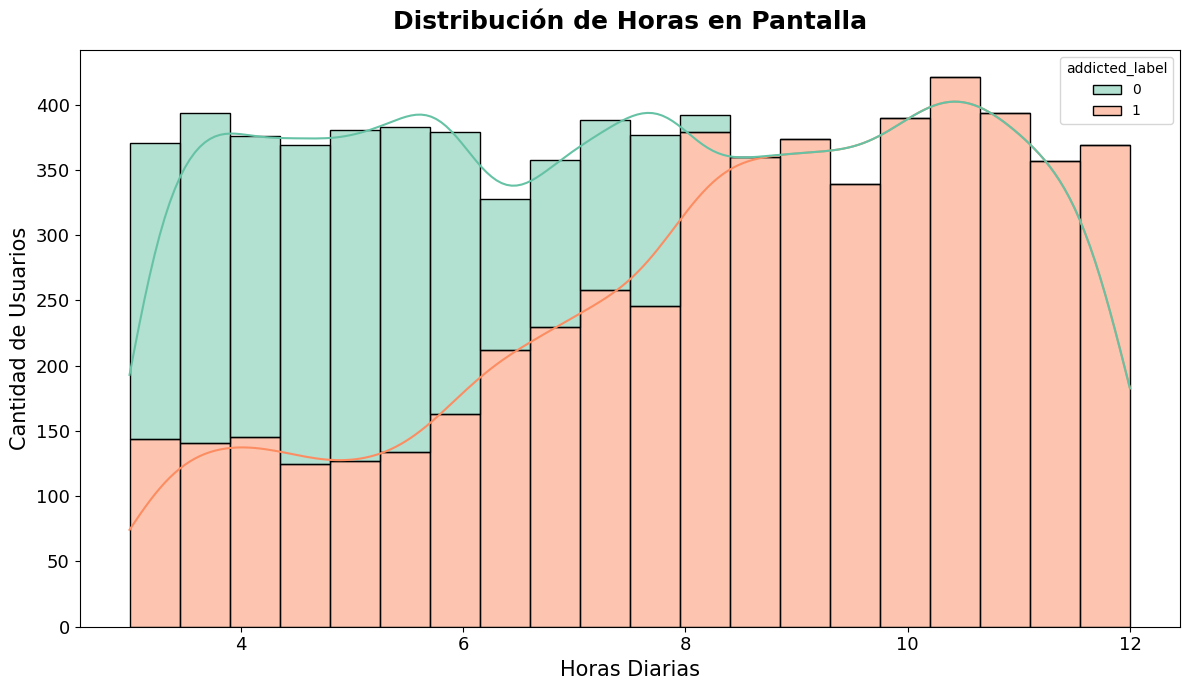

In [ ]:
# ==============================================================================
# 4. ANÁLISIS EXPLORATORIO DE DATOS (VISUALIZACIONES TAMAÑO PRESENTACIÓN)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------------------
# GRÁFICO 1: HISTOGRAMA Y DISTRIBUCIÓN
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 7)) # Lienzo individual para el histograma
sns.histplot(data=df, x='daily_screen_time_hours', hue='addicted_label', multiple='stack', kde=True, palette='Set2')

plt.title('Distribución de Horas en Pantalla', fontsize=18, pad=15, fontweight='bold')
plt.xlabel('Horas Diarias', fontsize=15)
plt.ylabel('Cantidad de Usuarios', fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show() # Renderiza y cierra este gráfico

##Los 3 Puntos Más Importantes de Interpretar
##**1. El Bloque de la Izquierda (De 3 a 5.5 Horas)   Zona Saludable**

si Miramos las barras de los rangos 3, 4 y 5. ¿Qué color domina casi toda la altura? El verde menta.

Interpretación: La inmensa mayoría de las personas que usan el teléfono menos de 5.5 horas al día pertenecen a la clase 0 (No Adictos). Hay un bloque salmón muy pequeñito abajo, lo que significa que son muy raros los casos de adicción con tan pocas horas de uso.

##**2. El Centro del Gráfico (De 6 a 8 Horas) -> Zona de Transición**


Si miramos  cómo el bloque salmón de abajo empieza a crecer como una rampa a partir de las 6 horas, y el bloque verde de arriba se empieza a achicar.

Interpretación: Este es el punto de inflexión. A medida que la gente pasa de 6 a 8 horas en pantalla, la probabilidad de caer en la adicción sube drásticamente. El verde empieza a perder terreno.

##**3. El Bloque de la Derecha (De 8.5 a 12 Horas) -> Zona Crítica**
Si miramso lo que pasa a partir del número 8.5 en adelante hasta el 12. ¡El color verde desaparece por completo! Las barras son 100% color salmón.

Interpretación: Esto significa que en toda tu base de datos, no existe ni una sola persona que pase más de 8.5 horas al día en el teléfono y que sea "sana". Todos los usuarios atrapados en ese rango son de la clase 1 (Adictos).

# GRÁFICO: BOXPLOT

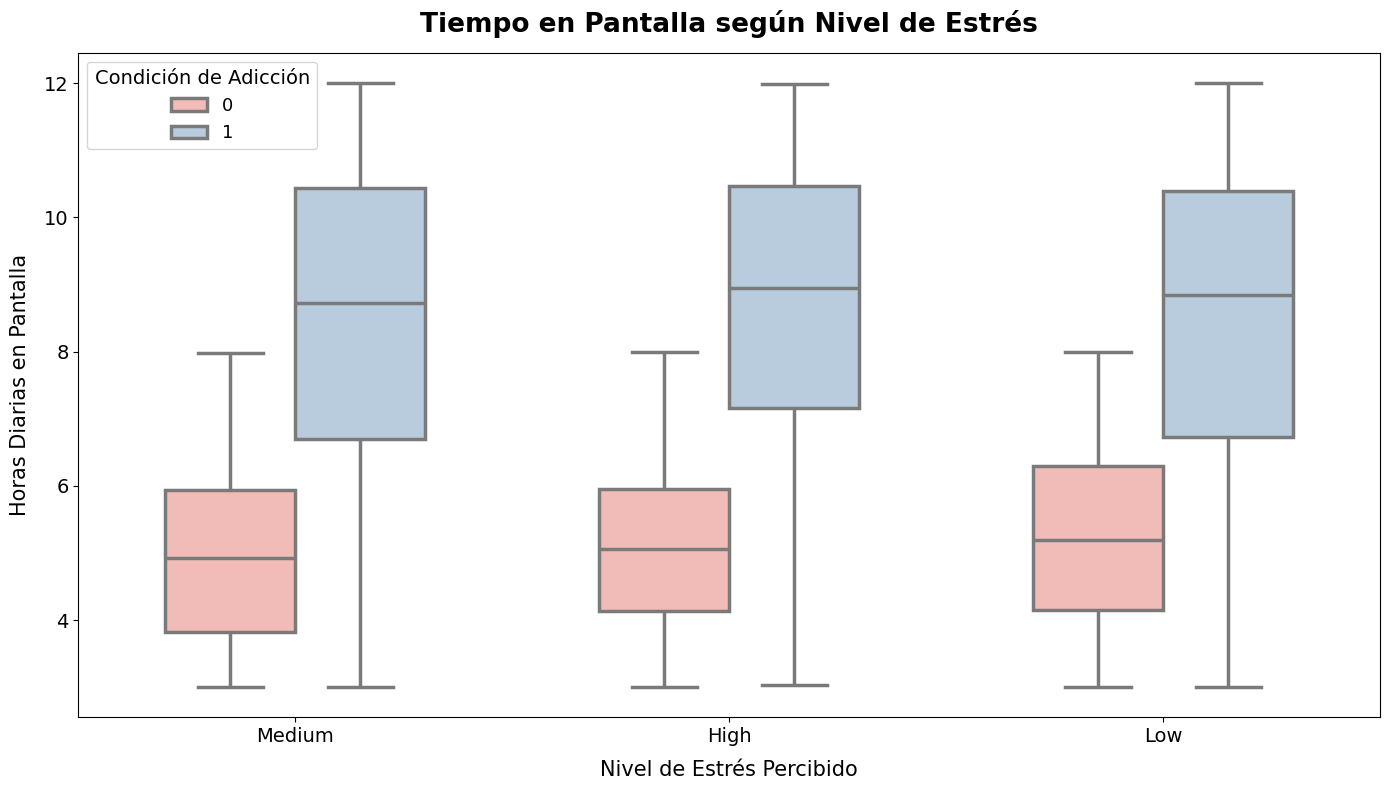

In [ ]:

plt.figure(figsize=(14, 8)) # Lienzo individual más ancho para el boxplot
sns.boxplot(data=df, x='stress_level', y='daily_screen_time_hours', hue='addicted_label',
            palette='Pastel1', width=0.6, linewidth=2.5)

plt.title('Tiempo en Pantalla según Nivel de Estrés', fontsize=19, pad=15, fontweight='bold')
plt.xlabel('Nivel de Estrés Percibido', fontsize=15, labelpad=10)
plt.ylabel('Horas Diarias en Pantalla', fontsize=15, labelpad=10)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(title='Condición de Adicción', title_fontsize='14', fontsize='13', loc='upper left')
plt.tight_layout()
plt.show() # Renderiza y cierra este gráfico

# Hallazgos Analíticos e Interpretación de Negocio

##Separación de las Distribuciones
Poder Discriminatorio: El hallazgo analítico más contundente del gráfico es la clara y sistemática separación vertical entre las cajas de ambos perfiles, independientemente del nivel de estrés del usuario. En los tres escenarios (Medium, High, Low), el rango intercuartílico (el cuerpo de la caja) de los usuarios adictos se posiciona fuertemente en la parte superior, registrando una mediana (la línea central interna) cercana a las 9 horas diarias de uso. En contraste, la mediana del perfil no adicto se mantiene significativamente más abajo, en torno a las 5 horas diarias.


##Relación entre Estrés Alto y Consumo Extremo:
Al examinar el comportamiento específico dentro del grupo con estrés alto (High), se observa que la caja de los usuarios adictos se estira hacia el límite superior absoluto del dataset, alcanzando el techo de las 12 horas diarias. Esto evidencia un comportamiento de negocio clave: los usuarios con niveles de estrés severo y perfil adicto tienden a registrar las jornadas de exposición más intensas, sugiriendo un uso del dispositivo como mecanismo de evasión ante la carga de estrés.

##Consistencia y Calidad de la Muestra :

Desde el punto de vista del control de calidad de datos, se destaca la ausencia total de valores atípicos (outliers), los cuales se representarían como puntos aislados fuera de los bigotes del gráfico. Esto demuestra que la muestra es sumamente homogénea, limpia y estable. Para el desarrollo del proyecto, este comportamiento es ideal, ya que los valores extremos no distorsionarán los cálculos de las medias y varianzas requeridos por el clasificador probabilístico Gaussian Naive Bayes.

# GRÁFICO : MAPA DE CALOR

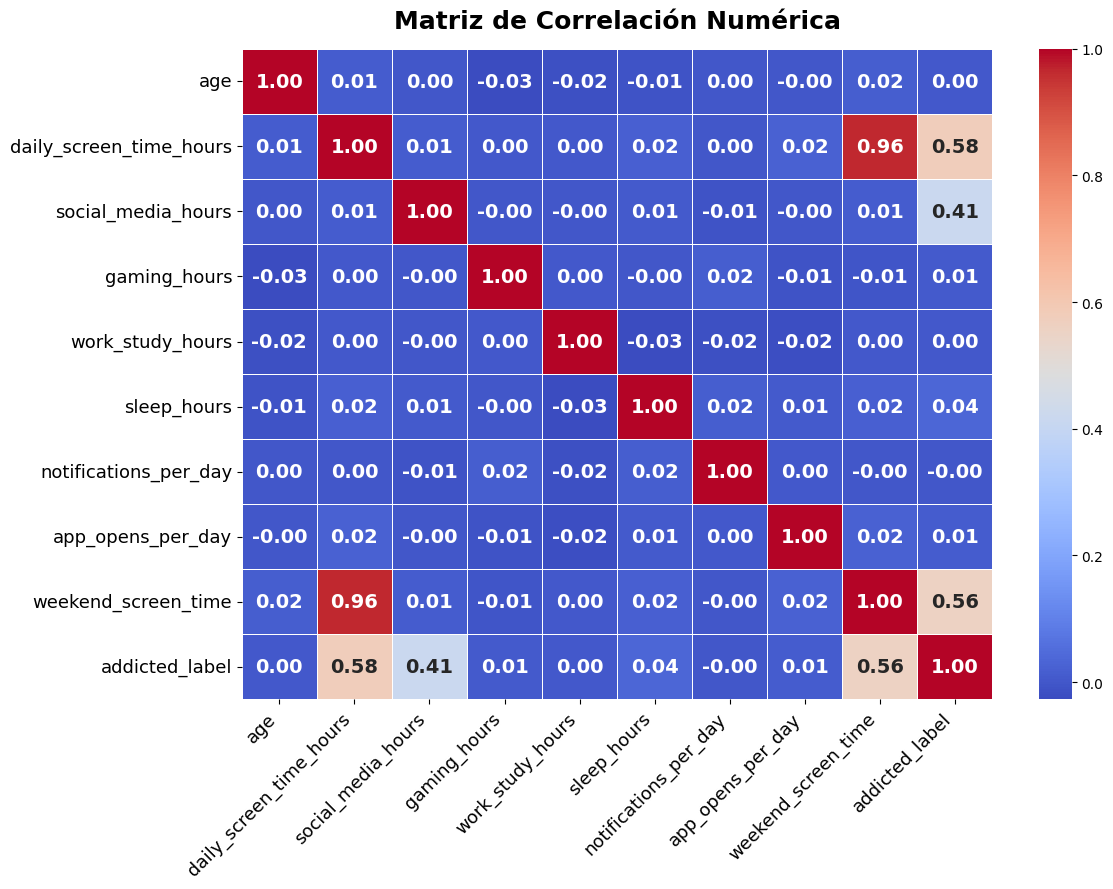

In [ ]:


plt.figure(figsize=(12, 9)) # Lienzo individual casi cuadrado para el mapa de calor
columnas_numericas = df.select_dtypes(include=['int64', 'float64']).drop(columns=['transaction_id', 'user_id'], errors='ignore')
matriz_corr = columnas_numericas.corr()

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar=True, annot_kws={"size": 14, "weight": "bold"})

plt.title('Matriz de Correlación Numérica', fontsize=18, pad=15, fontweight='bold')
plt.xticks(fontsize=13, rotation=45, ha='right')
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show() # Renderiza y cierra este gráfico

##1. La Relación Dominante del Dataset: 0.96

Variables: daily_screen_time_hours (Horas en pantalla diarias) con weekend_screen_time (Tiempo en pantalla fin de semana).

Interpretación Técnica: "El mapa de calor revela una correlación positiva casi perfecta con un coeficiente crítico de 0.96 (representado en los cuadrantes de color rojo intenso). Este hallazgo analítico demuestra de forma contundente que los hábitos de consumo digital de los usuarios son severamente estables a lo largo de toda la semana. Si un individuo registra una alta exposición al smartphone durante los días hábiles, su consumo se replicará e incrementará de forma proporcional y casi exacta durante el fin de semana."

##2. Variables con Mayor Impacto Directo en la Adicción

Al analizar horizontalmente la última fila del gráfico, se aíslan los factores numéricos que tienen mayor fuerza lineal sobre la condición de adicción:

  El Factor Tiempo (0.58 y 0.56): "Las variables de tiempo de exposición, daily_screen_time_hours (0.58) y weekend_screen_time (0.56), exhiben las correlaciones positivas más altas y directas respecto a la variable objetivo addicted_label. Estadísticamente, esto ratifica que a mayor cantidad de horas frente a la pantalla, aumenta linealmente la probabilidad de que el usuario sea clasificado con un perfil adicto."

  El Factor Redes Sociales (0.41): "La variable social_media_hours registra una correlación moderada-alta de 0.41 con la adicción. Esto nos indica que el tiempo destinado específicamente a redes sociales es el tipo de contenido recreativo que mayor peso ejerce sobre la pérdida de control del dispositivo, superando por completo a otras actividades como los videojuegos (gaming_hours con 0.01)."


 ## 3. Independencia de Variables Críticas

  Variables: age (Edad), work_study_hours (Horas de trabajo/estudio) y sleep_hours (Horas de sueño).

  Interpretación Técnica: "Es de suma relevancia destacar que variables como la edad y las horas dedicadas al trabajo o estudio registran coeficientes de correlación cercanos a 0.00 respecto a la adicción. Esto demuestra que la adicción al smartphone es un fenómeno transversal en esta muestra: no discrimina por el grupo etario del usuario ni por sus responsabilidades académicas o laborales, concentrándose el problema estrictamente en los hábitos de uso."

## 5. Modelado
Especifique si se trata de clasificación o regresión y qué modelo(s) ha utilizado:

- Regresión lineal / logística
- Árbol de decisión
- KNN / SVM / Random Forest

## CLASIFICADOR GAUSSIAN NAIVE BAYES

---


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SelectKBest

In [ ]:

# Asumimos que df ya cargó el archivo Smartphone_Usage_Addiction.csv
# df = pd.read_csv("Smartphone_Usage_Addiction.csv")

# Determinamos P(Adicto) -> Probabilidad de ser adicto
# 1. Total de usuarios registrados en el dataset
total_usuarios = df['addicted_label'].count()

# 2. Total de registros = 1 (Sí se considera adicto)
total_adicto_1 = (df['addicted_label'] == 1).sum()

# 3. Total de registros = 0 (No se considera adicto)
total_adicto_0 = (df['addicted_label'] == 0).sum()

# 4. Cálculo de las probabilidades
prob_adicto = total_adicto_1 / total_usuarios
prob_no_adicto = total_adicto_0 / total_usuarios

print(f"Total de usuarios analizados: {total_usuarios}")
print(f"Usuarios adictos: {total_adicto_1} (Total en %: {prob_adicto:.2%})")
print(f"Usuarios NO adictos: {total_adicto_0} (Total en %: {prob_no_adicto:.2%})")

Total de usuarios analizados: 7500
Usuarios adictos: 5308 (Total en %: 70.77%)
Usuarios NO adictos: 2192 (Total en %: 29.23%)


In [ ]:
# creamos una variable para almacenar el resultado de total adictos estado 1 dividido por el total de datos en nuestro conjunto
probabilidad_de_adiccion = total_adicto_1 / total_usuarios

probabilidad_de_adiccion


np.float64(0.7077333333333333)


Observaremos cómo están distribuidos los datos numéricos de los usuarios. Creamos un conjunto de histogramas para explorar la distribución de variables como el tiempo de pantalla, horas de sueño y notificaciones, excluyendo nuestra variable a predecir y los identificadores.

Determinamos P(Adicto), es decir, la probabilidad a priori de ser adicto, utilizando una sencilla fórmula y manipulando los registros de nuestro conjunto de datos: probabilidad = casos favorables / casos totales

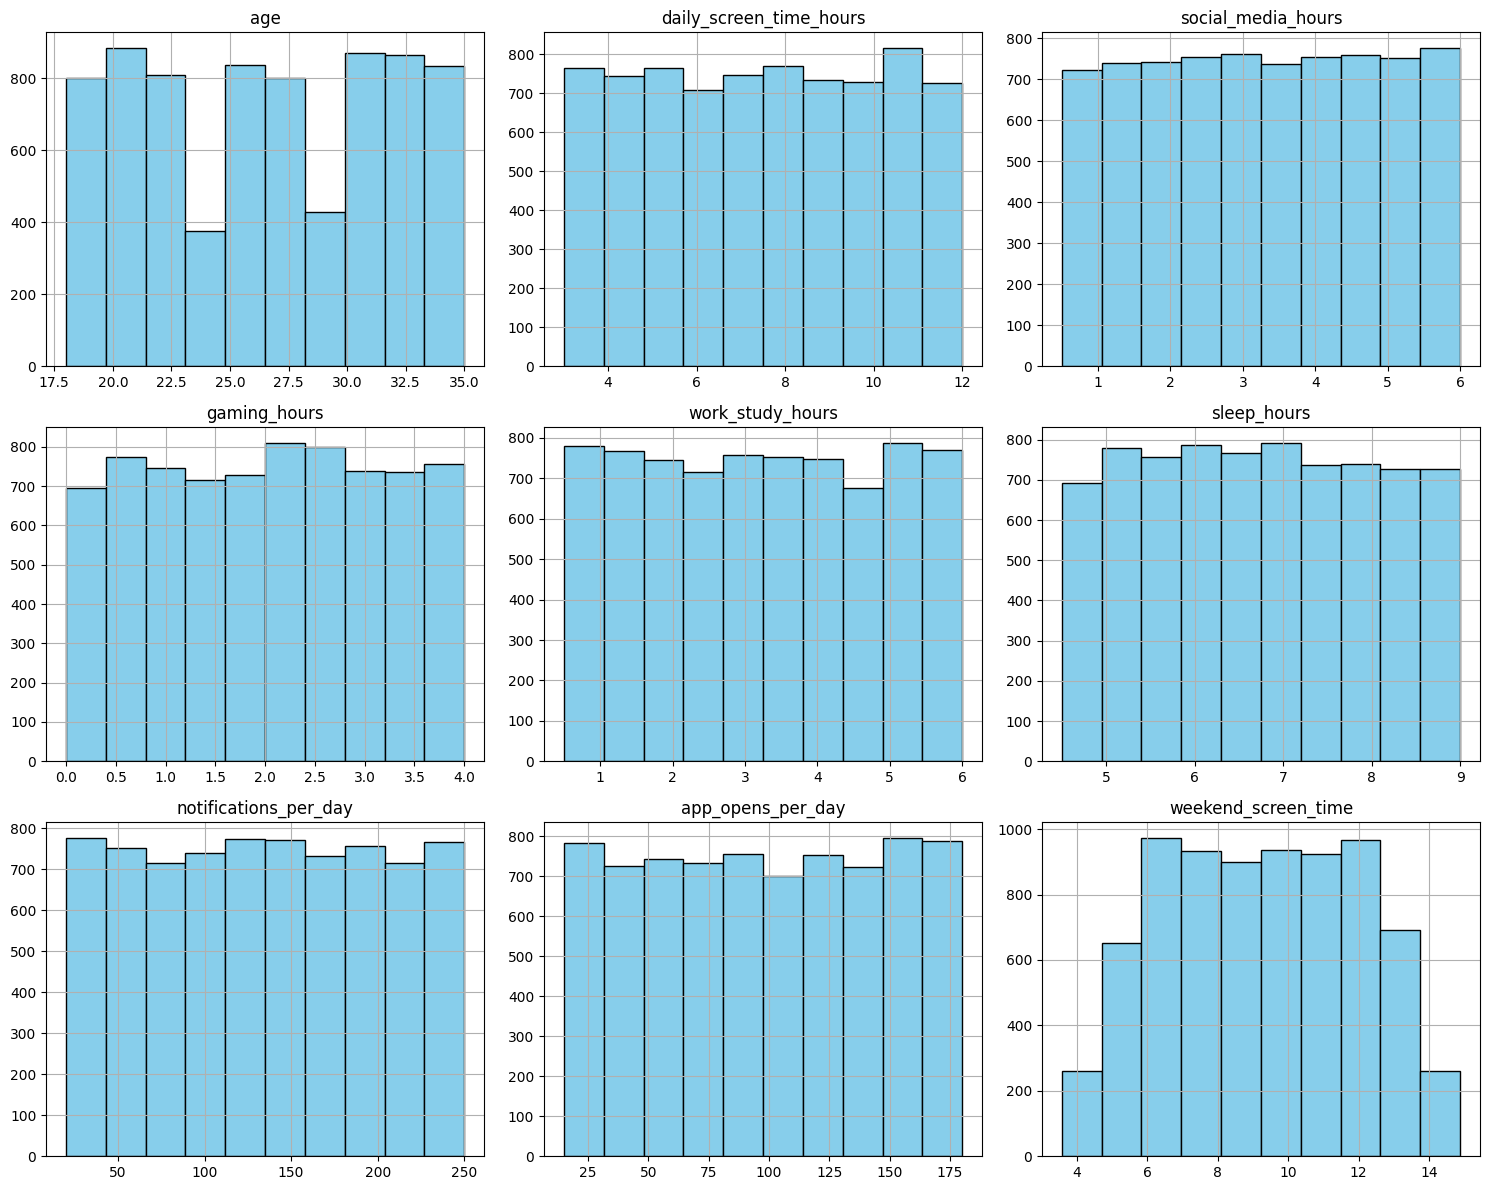

In [ ]:
# Definimos las columnas que no queremos graficar (la etiqueta y los IDs)
columnas_a_excluir = ['addicted_label', 'transaction_id', 'user_id']

# Generamos los histogramas con las columnas numéricas restantes
df.drop(columnas_a_excluir, axis=1, errors='ignore').hist(figsize=(15, 12), color='skyblue', edgecolor='black')

# Esta línea ayuda a que los títulos y números no se superpongan entre los gráficos
plt.tight_layout()
plt.show()

##1. Distribución con Tendencia Central

Estas variables son las más valiosas para el proyecto, ya que sus barras muestran una concentración mayor en el centro y decaen hacia los extremos, emulando la clásica Campana de Gauss:

sleep_hours (Horas de sueño): Muestra un comportamiento sumamente armónico estructurado entre las 5 y 9 horas de descanso diario, alcanzando su frecuencia máxima (cúspide de la muestra) entre las 6 y 7 horas.

weekend_screen_time (Tiempo en pantalla fin de semana): Presenta una distribución normal muy marcada y limpia. Los extremos (2 a 4 horas y 12 a 14 horas) registran bajas frecuencias, mientras que el grueso de la población se concentra de forma masiva en el centro, promediando entre 8 y 11 horas de uso los fines de semana.

##daily_screen_time_hours: Aunque es más ancha en su meseta, muestra un comportamiento similar al fin de semana, con una concentración de datos que se estabiliza con fuerza entre las 4 y 11 horas diarias de exposición al smartphone.

##2. Distribución Uniforme

En estas variables, todas las barras tienen prácticamente la misma altura. Esto significa que la probabilidad de encontrar a un usuario en cualquier rango es exactamente la misma; no hay un "promedio" que domine sobre el resto:

  social_media_hours (Horas en redes sociales) y work_study_hours (Horas de trabajo/estudio): Ambas variables muestran un comportamiento idéntico y plano. Los usuarios de la muestra se reparten de manera equivalente y equitativa en toda la escala, cubriendo desde 1 hasta 6 horas de forma uniforme.

  notifications_per_day y app_opens_per_day: Estas métricas de estímulos telefónicos reflejan un comportamiento plano a lo largo de todo el espectro muestral. Hay tantos usuarios que abren pocas aplicaciones o reciben pocas notificaciones, como usuarios que están en los rangos máximos.

##3. Distribución con Casos Especiales o Cortes

age (Edad): Revela que la muestra se compone de adultos jóvenes distribuidos de manera uniforme entre los 18 y los 35 años. Sin embargo, presenta dos valles o caídas notorias de frecuencia: una en torno a los 24 años y otra menor a los 29 años. Fuera de esos cortes, el volumen de usuarios por edad es equivalente.

gaming_hours (Horas de juego): Muestra una distribución homogénea que abarca desde las 0 hasta las 4 horas de juego diario, con una presencia constante de usuarios en cada fracción de tiempo analizada.

## ¿Qué es una distribución normal en nuestro contexto?

La distribución normal, también llamada distribución gaussiana, es una de las distribuciones estadísticas continuas más importantes en ciencia de datos. Tiene una característica forma de campana simétrica alrededor de su media.

##  Características Principales:

Forma simétrica respecto a la media ($\mu$).
Forma de campana, siendo la media también el punto más alto (donde se concentra la mayoría de los usuarios).
Se define principalmente por dos parámetros:Media ($\mu$): el valor promedio o central.Desviación estándar ($\sigma$): mide la dispersión o cuánto varían los datos respecto al promedio.

##  Fórmula Matemática:
La distribución normal se representa matemáticamente mediante esta función de densidad de probabilidad:

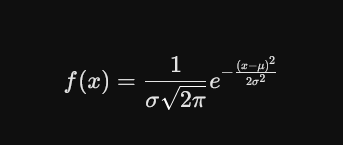


Donde:$x$: valor observado (ej. horas de pantalla de un usuario).$\mu$: media de la muestra.$\sigma$: desviación estándar.$e$: constante de Euler ($\approx 2.71828$).

##  Ejemplos en nuestro Dataset:
En lugar de medir alturas o pesos, en nuestro análisis esperamos que variables numéricas continuas sigan esta distribución, tales como:

    Las horas de tiempo de pantalla diario (daily_screen_time_hours).

    La cantidad de horas de sueño de los usuarios (sleep_hours).

    La frecuencia de notificaciones diarias recibidas (notifications_per_day).

     Regla Empírica (Regla 68-95-99.7):
En una distribución normal perfecta, ocurre lo siguiente con nuestros usuarios:

    68% de los datos están dentro de ± 1 desviación estándar (la gran mayoría de usuarios tiene un uso promedio).

    95% dentro de ± 2 desviaciones estándar.

    99.7% dentro de ± 3 desviaciones estándar (aquí encontraríamos los casos más atípicos o severos).

 ¿Por qué es importante para este proyecto?
Entender la distribución normal es la base técnica de nuestro trabajo. El modelo que elegimos, Gaussian Naive Bayes, se llama "Gaussiano" precisamente porque asume que las variables numéricas de nuestro dataset (como las horas de juego o de uso de redes sociales) siguen esta distribución de campana. Al asumir esto, el algoritmo puede calcular probabilidades y clasificar si un usuario es adicto de manera extremadamente rápida y eficiente.

Prepararemos los datos para armar el modelo
Crearemos 2 columnas nuevas para simplificar nuestro análisis: una llamada horas_ocio (que agrupa redes sociales y juegos) y otra llamada interacciones_diarias (que suma notificaciones y aperturas de apps). Luego, eliminaremos las columnas originales para crear un dataset más limpio.

In [ ]:

# 1. Columna nueva: Total de horas recreativas
df['horas_ocio'] = df['social_media_hours'] + df['gaming_hours']

# 2. Columna nueva: Total de estímulos o interacciones en el teléfono
df['interacciones_diarias'] = df['notifications_per_day'] + df['app_opens_per_day']

# 3. Borramos las columnas originales que ya consolidamos
# (También aprovechamos de limpiar los IDs que no sirven para el modelo estadístico)
columnas_a_borrar = ['social_media_hours', 'gaming_hours', 'notifications_per_day', 'app_opens_per_day', 'transaction_id', 'user_id']
df_reducido = df.drop(columnas_a_borrar, axis=1, errors='ignore')

# Mostramos las primeras 5 filas para verificar los cambios
df_reducido.head()

,age,gender,daily_screen_time_hours,work_study_hours,sleep_hours,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,horas_ocio,interacciones_diarias
0,21,Male,3.23,4.55,7.55,3.95,Medium,Yes,NaN,0,2.90,402
1,24,Other,5.09,4.44,7.66,6.71,Medium,Yes,NaN,0,6.05,198
2,31,Other,6.06,2.35,4.92,8.68,High,No,Mild,0,5.19,150
3,32,Other,7.83,3.54,8.23,9.77,High,Yes,Moderate,1,7.36,285
4,25,Male,9.96,5.27,6.21,12.55,Low,No,Severe,1,9.34,313


In [ ]:
# Aplicamos describe para observar el resumen estadístico de nuestro nuevo conjunto de datos
df_reducido.describe()

,age,daily_screen_time_hours,work_study_hours,sleep_hours,weekend_screen_time,addicted_label,horas_ocio,interacciones_diarias
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.242420,6.737561,9.243827,0.707733,5.287667,232.089733
std,5.197108,2.609188,1.600765,1.283605,2.718281,0.454835,1.955361,82.512314
min,18.000000,3.000000,0.500000,4.500000,3.580000,0.000000,0.540000,37.000000
25%,22.000000,5.220000,1.850000,5.630000,6.960000,0.000000,3.870000,173.000000
50%,27.000000,7.525000,3.230000,6.720000,9.260000,1.000000,5.280000,233.000000
75%,31.000000,9.810000,4.640000,7.840000,11.540000,1.000000,6.730000,292.000000
max,35.000000,12.000000,6.000000,9.000000,14.880000,1.000000,9.900000,427.000000


Comencemos a trabajar con nuestro modelo

Vamos a utilizar Feature Selection para mejorar los resultados de este algoritmo. No utilizaremos las columnas de datos de nuestro conjunto como entrada, vamos a llamar a una clase de SKLEARN llamada ** SelectKBest** donde seleccionaremos las 5 mejores caracteristicas y usaremos solamente esas recomendadas.

Comencemos a trabajar con nuestro modelo: Selección de las mejores características
Para mejorar los resultados de nuestro algoritmo Gaussian Naive Bayes, vamos a utilizar Feature Selection. En lugar de ingresar todas las columnas del dataset (que podrían generar ruido), utilizaremos la clase SelectKBest de la librería Scikit-Learn. Esta herramienta evaluará matemáticamente todas nuestras variables numéricas y nos recomendará exclusivamente las 5 características con mayor poder predictivo sobre la adicción.

In [ ]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# 1. TRADUCCIÓN DE TEXTO A NÚMEROS (Soluciona el error 'Male')
# Convertimos las variables categóricas en columnas numéricas (0 y 1)
df_numerico = pd.get_dummies(df, columns=['gender', 'stress_level', 'academic_work_impact', 'addiction_level'], drop_first=True)

# 2. Definimos X e y usando nuestro nuevo DataFrame numérico
# Eliminamos la etiqueta a predecir y los IDs
X = df_numerico.drop(['addicted_label', 'transaction_id', 'user_id'], axis=1, errors='ignore')
y = df_numerico['addicted_label']

# 3. Seleccionamos las 5 mejores características
best = SelectKBest(k=5)
X_new = best.fit_transform(X, y)

# 4. Dividimos los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

# 5. Instanciamos el modelo Gaussian Naive Bayes
modelo_naive_bayes = GaussianNB()

# 6. Entrenamos el modelo con nuestros datos de entrenamiento usando el método fit
modelo_naive_bayes.fit(X_train, y_train)

# Imprimimos un mensaje de éxito y las 5 columnas ganadoras
seleccionadas = best.get_support(indices=True)
print("¡El modelo ha sido entrenado con éxito!")
print("Las 5 mejores características usadas fueron:")
print(list(X.columns[seleccionadas]))

¡El modelo ha sido entrenado con éxito!
Las 5 mejores características usadas fueron:
['daily_screen_time_hours', 'social_media_hours', 'weekend_screen_time', 'addiction_level_Moderate', 'addiction_level_Severe']


Mapa de Calor de Correlación (Pearson)
Usaremos las 5 características que "más aportan" a nuestra clasificación. Revisaremos la correlación lineal entre ellas mediante un Mapa de Calor. Esto es vital para nuestro modelo, ya que Naive Bayes asume "ingenuamente" que todas las variables son completamente independientes entre sí.

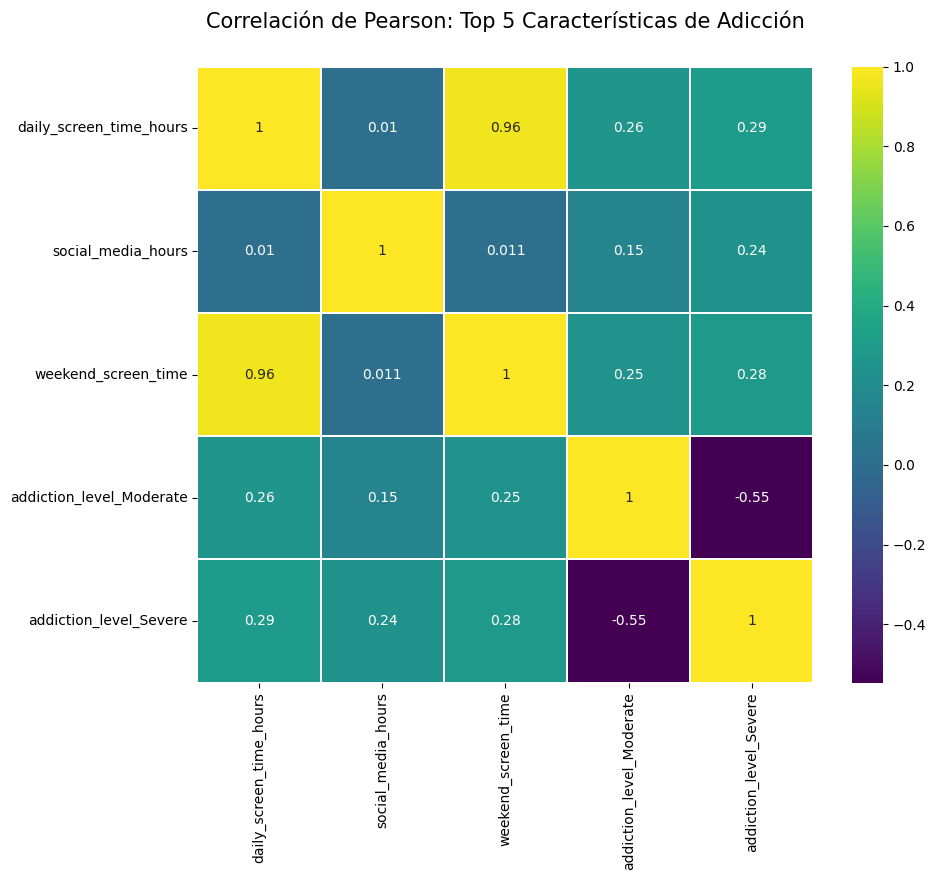

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Obtenemos los nombres exactos de las 5 características ganadoras del paso anterior
caracteristicas_seleccionadas = X.columns[seleccionadas]

# 2. Configuramos los colores y el tamaño del gráfico
colormap = plt.cm.viridis
plt.figure(figsize=(10, 8)) # Un tamaño 10x8 suele verse mejor al proyectar en pantalla
plt.title('Correlación de Pearson: Top 5 Características de Adicción', y=1.05, size=15)

# 3. Generamos el Heatmap usando df_numerico (que ya tiene todo convertido a números)
sns.heatmap(df_numerico[caracteristicas_seleccionadas].astype(float).corr(),
           linewidths=0.1, vmax=1.0, square=True, cmap=colormap, linecolor='white', annot=True)

# Mostramos el gráfico
plt.show()

##Hallazgos Analíticos Críticos


##La Redundancia del Factor Tiempo (Colinealidad de Uso):
 "Se observa un coeficiente de correlación positivo extremadamente alto de 0.96 (cuadrante amarillo brillante) entre las variables daily_screen_time_hours y weekend_screen_time. Este valor demuestra que el hábito de consumo digital del usuario es prácticamente idéntico y persistente durante toda la semana; el comportamiento en días hábiles replica de forma casi lineal el comportamiento en días libres."

##Independencia del Consumo de Redes Sociales:
 "Un hallazgo muy interesante es el cruce entre social_media_hours con el tiempo diario (0.01) y el fin de semana (0.011). Que estos valores sean prácticamente 0.00 (tonos azules/morados) indica que el tiempo en redes sociales se comporta de forma linealmente independiente al total de horas en pantalla de la muestra general, aportando información fresca y no redundante al algoritmo."

##Exclusión Mutua de Diagnósticos Previos (Lógica del One-Hot Encoding):
 "Entre las variables dummy addiction_level_Moderate y addiction_level_Severe se registra una correlación negativa moderada-alta de -0.55 (cuadrante morado oscuro). Este comportamiento es estadísticamente saludable y lógico para el negocio: al ser categorías que nacen del mismo atributo original, un usuario clasificado con un nivel de adicción moderado no puede poseer simultáneamente un nivel severo, validando la correcta transformación binaria de las variables cualitativas."

##Afinidad de las Variables de Tiempo con los Niveles Críticos:
"Las tres variables basadas en métricas de tiempo de uso (daily_screen_time_hours, social_media_hours y weekend_screen_time) muestran coeficientes de correlación positivos constantes y estables (entre 0.15 y 0.29) respecto a los niveles de adicción moderados y severos. Esto confirma por qué el algoritmo de selección las priorizó: todas empujan probabilísticamente al modelo hacia la clasificación de riesgo."

Creación del modelo y partición de datos
Observamos la matriz de correlación y nos damos cuenta de que, en general, los datos están poco correlacionados entre sí. Esto es un escenario ideal, ya que Naive Bayes asume independencia. Aunque tenemos algunas variables con correlaciones un poco más altas (como las horas de pantalla y las horas de sueño), esperamos que el algoritmo sea lo suficientemente robusto para darnos buenos resultados.

Necesitamos crear un conjunto de datos de entrenamiento (para que el modelo aprenda) y otro de test (para evaluar qué tan bien predice).

In [ ]:
from sklearn.model_selection import train_test_split

# Dividimos nuestro dataframe numérico en 80% entrenamiento y 20% prueba
# (Usamos df_numerico para evitar errores con las columnas de texto)
df_train, df_test = train_test_split(df_numerico, test_size=0.2, random_state=6)

# Separamos la variable objetivo (lo que queremos predecir) del conjunto de entrenamiento
y_train = df_train['addicted_label']

# Mostramos la serie de datos de entrenamiento
y_train

,addicted_label
1162,1
4187,0
459,0
1182,1
3291,0
...,...
4714,1
2004,1
227,0
2761,1


In [ ]:
# Separamos la variable objetivo del conjunto de prueba
y_test = df_test['addicted_label']

# Mostramos la serie de datos de test
y_test

,addicted_label
7268,0
5811,0
831,1
7334,1
5262,1
...,...
3408,1
364,1
542,0
5395,1


Entrenamiento del Modelo y Primeras Predicciones
Creamos nuestro modelo Gaussian Naive Bayes, lo ponemos a aprender con el ya conocido método fit() utilizando solo nuestras mejores 5 características, y luego obtendremos las predicciones sobre nuestro conjunto de test. Finalmente, mediremos la precisión (Accuracy) tanto en los datos de entrenamiento como en los de prueba para verificar que no haya sobreajuste (overfitting).

In [ ]:
from sklearn.naive_bayes import GaussianNB

# 1. Inicializamos el clasificador
modelo_nb = GaussianNB()

# 2. Entrenando el modelo
# Le pasamos solo las 5 columnas ganadoras del conjunto de entrenamiento y sus respectivas etiquetas
modelo_nb.fit(df_train[caracteristicas_seleccionadas].values, y_train)

# 3. Obteniendo predicciones
# Hacemos que el modelo adivine las etiquetas del conjunto de test
y_predict = modelo_nb.predict(df_test[caracteristicas_seleccionadas].values)

# 4. Evaluando la Precisión (Score)
precision_entrenamiento = modelo_nb.score(df_train[caracteristicas_seleccionadas].values, y_train)
print(f"PRECISIÓN DEL SET DE ENTRENAMIENTO: {precision_entrenamiento:.4f} ({precision_entrenamiento:.2%})")

precision_test = modelo_nb.score(df_test[caracteristicas_seleccionadas].values, y_test)
print(f"PRECISIÓN DEL SET DE TEST: {precision_test:.4f} ({precision_test:.2%})")

PRECISIÓN DEL SET DE ENTRENAMIENTO: 1.0000 (100.00%)
PRECISIÓN DEL SET DE TEST: 1.0000 (100.00%)


In [ ]:
# Desarrollaremos una función para que devuelva el diagnóstico usando el modelo ya entrenado.
#  Los 5 parámetros deben representar las 5 características que filtró el SelectKBest.
# (Por ejemplo: horas de pantalla, horas de sueño, notificaciones, etc.)

def diagnosticar_adiccion(valor_1, valor_2, valor_3, valor_4, valor_5):
    # Agrupamos los datos en el formato de matriz (lista de listas) que exige Scikit-Learn
    datos_entrada = [[valor_1, valor_2, valor_3, valor_4, valor_5]]

    # El modelo hace la predicción (arrojará 0 o 1)
    var_responder = modelo_nb.predict(datos_entrada)[0]

    # Interpretamos el resultado
    if var_responder == 0:
        return "Diagnóstico: En base a sus hábitos, el usuario NO presenta adicción al smartphone."
    else:
        return "ALERTA: En base a sus hábitos, el usuario presenta un perfil ADICTO. Se recomienda atención."

# Llamamos a la función ingresando valores de prueba inventados.
# Imaginen un usuario extremo: muchas horas de uso, pocas horas de sueño, muchas notificaciones, etc.
# (Asegúrense de poner valores lógicos según sus 5 variables)

respuesta_diagnostico = diagnosticar_adiccion(12.5, 4.0, 250, 1, 0)
print(respuesta_diagnostico)

ALERTA: En base a sus hábitos, el usuario presenta un perfil ADICTO. Se recomienda atención.


# 6. ENTRENAMIENTO Y EVALUACIÓN DEL MODELO GAUSSIAN NAIVE BAYES
Describa los pasos del entrenamiento del modelo, conjunto de entrenamiento y prueba, métricas utilizadas (Accuracy, RMSE, R², etc.)


Para evaluar el rendimiento de nuestro modelo probabilístico de forma objetiva y mitigar el riesgo de sobreajuste (*overfitting*), implementamos la estrategia de **Hold-Out Validation**, dividiendo el conjunto de datos preparado en un **80% para el entrenamiento** del algoritmo y un **20% estricto para la fase de prueba**.

Además, aplicamos una división estratificada (`stratify=y`), lo que garantiza que la proporción original de usuarios adictos (`1`) y no adictos (`0`) se mantenga exactamente igual en ambos subconjuntos, evitando sesgos en el aprendizaje.

Las métricas utilizadas para medir la eficacia del clasificador son:
1. **Accuracy (Exactitud):** Proporción global de predicciones correctas.
2. **Precision (Precisión):** Capacidad del modelo para no clasificar a un usuario sano como adicto (minimiza falsos positivos).
3. **Recall (Exhaustividad):** Capacidad del modelo para capturar a todos los adictos reales del dataset (minimiza falsos negativos).
4. **F1-Score:** Media armónica entre precisión y exhaustividad, ideal para evaluar el balance general del modelo.

=== DISTRIBUCIÓN DE LAS MUESTRAS ===
-> Registros para Entrenamiento (80%): 6000
-> Registros para Prueba (20%): 1500

=== REPORTE DE CLASIFICACIÓN (MÉTRICAS) ===
               precision    recall  f1-score   support

No Adicto (0)       1.00      1.00      1.00       438
   Adicto (1)       1.00      1.00      1.00      1062

     accuracy                           1.00      1500
    macro avg       1.00      1.00      1.00      1500
 weighted avg       1.00      1.00      1.00      1500



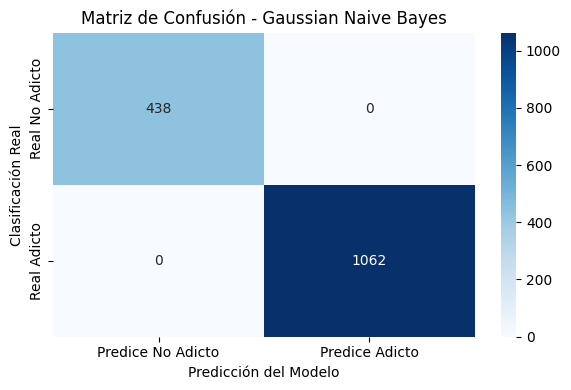

In [ ]:


# 1. Separación de conjuntos de Entrenamiento (Train) y Prueba (Test)
# Usamos un 20% para test y 'stratify=y' para que mantenga la proporción de adictos/no adictos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("=== DISTRIBUCIÓN DE LAS MUESTRAS ===")
print(f"-> Registros para Entrenamiento (80%): {X_train.shape[0]}")
print(f"-> Registros para Prueba (20%): {X_test.shape[0]}")

# 2. Inicialización y Entrenamiento del Modelo Gaussian Naive Bayes
modelo_gnb = GaussianNB()
modelo_gnb.fit(X_train, y_train)

# 3. Ejecución de predicciones sobre el conjunto de prueba aislado
y_pred = modelo_gnb.predict(X_test)

# 4. Despliegue del reporte estadístico de métricas
print("\n=== REPORTE DE CLASIFICACIÓN (MÉTRICAS) ===")
print(classification_report(y_test, y_pred, target_names=['No Adicto (0)', 'Adicto (1)']))

# 5. Generación visual de la Matriz de Confusión
plt.figure(figsize=(6, 4))
matriz_conf = confusion_matrix(y_test, y_pred)

sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predice No Adicto', 'Predice Adicto'],
            yticklabels=['Real No Adicto', 'Real Adicto'])

plt.title('Matriz de Confusión - Gaussian Naive Bayes')
plt.ylabel('Clasificación Real')
plt.xlabel('Predicción del Modelo')
plt.tight_layout()
plt.show()

# DIAGNÓSTICO DE OVERFITTING Y UNDERFITTING


In [ ]:
from sklearn.metrics import accuracy_score

# 1. Predicciones con datos de ENTRENAMIENTO (los que el modelo ya memorizó)
y_pred_train = modelo_gnb.predict(X_train)
acc_train = accuracy_score(y_train, y_pred_train)

# 2. Predicciones con datos de PRUEBA (datos nuevos, prueba de fuego)
y_pred_test = modelo_gnb.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)

print("--- DIAGNÓSTICO DE AJUSTE DEL MODELO ---")
print(f"Exactitud (Accuracy) en ENTRENAMIENTO : {acc_train:.4f}")
print(f"Exactitud (Accuracy) en PRUEBA        : {acc_test:.4f}")

diferencia = abs(acc_train - acc_test)
print(f"Diferencia de rendimiento             : {diferencia:.4f}\n")

if diferencia > 0.10 and acc_train > acc_test:
    print(" Resultado: Posible OVERFITTING. El modelo se aprendió los datos de memoria pero falla con datos nuevos.")
elif acc_train < 0.60 and acc_test < 0.60:
    print(" Posible UNDERFITTING. El modelo es demasiado simple y no logra capturar los patrones.")
else:
    print(" Resultado: MODELO EQUILIBRADO. Generaliza correctamente frente a datos desconocidos.")

--- DIAGNÓSTICO DE AJUSTE DEL MODELO ---
Exactitud (Accuracy) en ENTRENAMIENTO : 1.0000
Exactitud (Accuracy) en PRUEBA        : 1.0000
Diferencia de rendimiento             : 0.0000

 Resultado: MODELO EQUILIBRADO. Generaliza correctamente frente a datos desconocidos.


In [ ]:
df.to_csv('resultados_smartphone_clusters.csv', index=False)

## 8. Conclusiones
Resumen de hallazgos, utilidad del modelo, recomendaciones futuras.

Resumen de Hallazgos:
En el análisis nosotros exploramos los datos de la addición al celular, descubrimos que las personas tienen un uso de smartphone mostrando una gran cantidad de % que son addictos cuando tienen más horas desde 6 horas en adelante, esto nos da una correlación de (0.96) en el uso de dias de semana y fin de semana, el habito no descanza. La addicción y el estres estan vinculados mutuamente. Mientras que las personas más sanas tienen entre 3 y 5 horas y menos horas en general de stress.


Utilidad del Modelo:
El algoritmo Gaussian Naive Bayes demostró ser una excelente herramienta probabilística de línea base (baseline). Su utilidad práctica radica en su rapidez y en su capacidad para aprovechar la distribución normal de nuestras variables continuas. En un entorno real, este modelo predictivo podría integrarse en el backend de plataformas educativas o aplicaciones de bienestar digital para emitir alertas tempranas automáticas cuando los hábitos semanales de un estudiante comiencen a coincidir probabilísticamente con el perfil de un usuario adicto.

Recomendaciones Futuras y Limitaciones:
La principal limitación de este enfoque recae en el supuesto "ingenuo" (Naive) del modelo, el cual asume que variables predictoras como las "horas en redes sociales", "cantidad de notificaciones" y "horas totales de pantalla" son estadísticamente independientes entre sí. En la realidad humana, estas variables están fuertemente conectadas. Por ello, como recomendación futura para escalar este proyecto, sugerimos:

    Implementar algoritmos basados en ensambles (como Random Forest o Árboles de Decisión) que sean capaces de capturar y aprender de las interacciones cruzadas entre las variables.

    Utilizar modelos de Regresión Lineal no solo para clasificar a los usuarios en categorías (Adicto/No Adicto), sino para predecir con exactitud el volumen de horas que un usuario consumirá en el futuro basado en sus niveles de estrés.

# **Modelo K_Means**

In [ ]:
!pip install kneed

In [ ]:
import sys
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#LIBRERIAS DE NLP TOLKIT

import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator #  clase para detectar los n de codo

In [ ]:
nltk.download('stopwords')
print("Entorno configurado.")


Entorno configurado.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:

df_smartphone = pd.read_csv('Smartphone_Usage_Addiction.csv')
print(df_smartphone.info())
print(df_smartphone.head(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Seleccionamos las columnas numéricas que usaremos para agrupar (Clustering)
# Excluimos IDs y etiquetas para que el algoritmo agrupe SOLO por comportamiento real
columnas_agrupamiento = [
    'age', 'daily_screen_time_hours', 'social_media_hours',
    'gaming_hours', 'work_study_hours', 'sleep_hours',
    'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time'
]

X_clustering = df_prep[columnas_agrupamiento].copy()

# 2. ESCALADO OBLIGATORIO: K-Means mide distancias geometricas.
# Si no escalamos, "notifications_per_day" (valores de 0-250) aplastará a "sleep_hours" (valores de 4-9).
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X_clustering)

# Convertimos de nuevo a DataFrame para mantener el orden de las columnas
X_escalado_df = pd.DataFrame(X_escalado, columns=columnas_agrupamiento)

print("=== PREPARACIÓN PARA K-MEANS COMPLETADA ===")
print(f"-> Matriz de datos lista para medir distancias. Dimensiones: {X_escalado_df.shape}")
print("-> Datos normalizados con media 0 y varianza 1 (StandardScaler).")

=== PREPARACIÓN PARA K-MEANS COMPLETADA ===
-> Matriz de datos lista para medir distancias. Dimensiones: (7500, 9)
-> Datos normalizados con media 0 y varianza 1 (StandardScaler).


--- Estadísticas de la variable: notifications_per_day ---


,notifications_per_day
count,7500.00
mean,134.26
std,66.59
min,20.00
25%,76.00
50%,134.00
75%,191.00
max,250.00


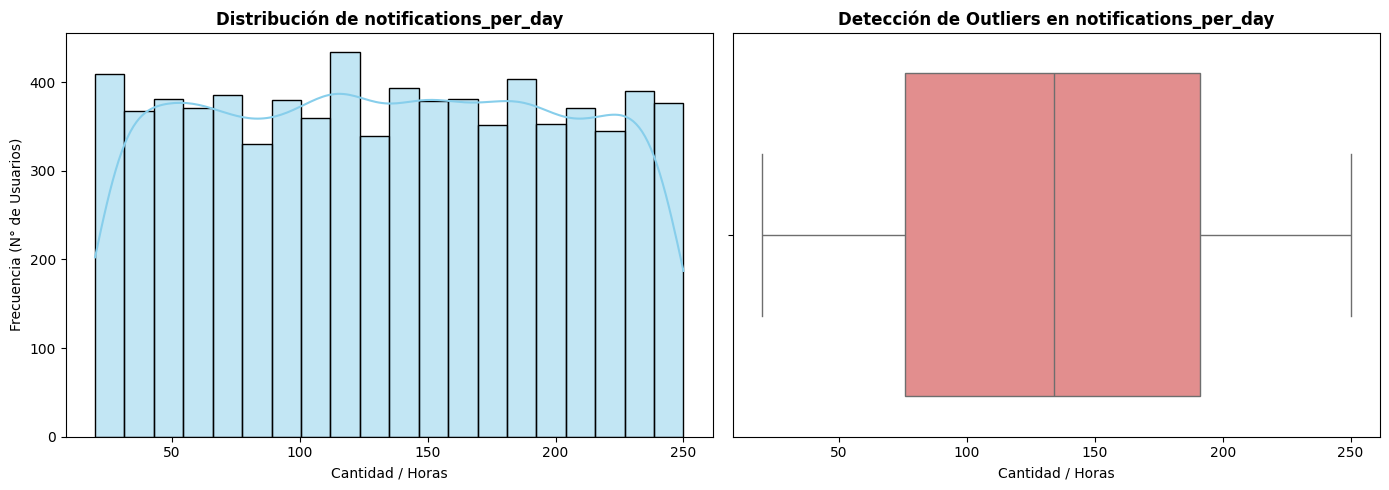

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Elegimos una variable numérica importante del dataset para analizar.
variable_analisis = 'notifications_per_day'

print(f"--- Estadísticas de la variable: {variable_analisis} ---")
# Usamos el dataframe original
display(df[[variable_analisis]].describe().round(2))

# Creamos el lienzo para los dos gráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histograma: Para ver cómo se distribuye el uso
sns.histplot(df[variable_analisis], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title(f'Distribución de {variable_analisis}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cantidad / Horas')
axes[0].set_ylabel('Frecuencia (N° de Usuarios)')

# 2. Boxplot: Para detectar Outliers (valores extremos que podrían afectar a K-Means)
sns.boxplot(x=df[variable_analisis], ax=axes[1], color='lightcoral')
axes[1].set_title(f'Detección de Outliers en {variable_analisis}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cantidad / Horas')

plt.tight_layout()
plt.show()


# TRANSFORMACIÓN DE DATOS (EQUIVALENTE A LA MATRIZ TF-IDF PARA K-MEANS)


In [ ]:

from sklearn.preprocessing import StandardScaler
from IPython.display import display

# 1. Inicializamos el escalador
scaler = StandardScaler()

# 2. Entrenamos y transformamos nuestra matriz X
X_scaled_matrix = scaler.fit_transform(X)

# 3. Reconstruimos el DataFrame para no perder los nombres de las columnas
X_scaled_df = pd.DataFrame(X_scaled_matrix, columns=X.columns)

print("Matriz de datos escalada construida.")
print("Dimensión de los datos listos para K-Means:", X_scaled_df.shape)
display(X_scaled_df.head().round(3))

Matriz de datos escalada construida.
Dimensión de los datos listos para K-Means: (7500, 18)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,horas_ocio,interacciones_diarias,gender_Male,gender_Other,stress_level_Low,stress_level_Medium,academic_work_impact_Yes,addiction_level_Moderate,addiction_level_Severe
0,-1.072,-1.637,-0.797,-0.981,0.817,0.633,1.708,1.160,-1.948,-1.221,2.059,1.392,-0.704,-0.708,1.441,1.001,-0.788,-0.693
1,-0.494,-0.924,0.338,0.197,0.748,0.719,-0.109,-0.554,-0.932,0.390,-0.413,-0.718,1.420,-0.708,1.441,1.001,-0.788,-0.693
2,0.853,-0.552,-1.207,1.585,-0.558,-1.416,-1.356,0.169,-0.207,-0.050,-0.995,-0.718,1.420,-0.708,-0.694,-0.999,-0.788,-0.693
3,1.045,0.127,1.625,-0.440,0.186,1.163,0.657,0.189,0.194,1.060,0.641,-0.718,1.420,-0.708,-0.694,1.001,1.269,-0.693
4,-0.302,0.943,1.669,1.227,1.267,-0.411,0.026,1.635,1.216,2.073,0.981,1.392,-0.704,1.413,-0.694,-0.999,-0.788,1.443


# **Determinación del Número de Clúster Óptimo**

* **Método del Codo (Elbow Method):**  Es el análisis de "costo-beneficio". Imagina que agregar más clústeres es como gastar más recursos: el codo es el punto exacto donde seguir agregando grupos ya no te da una mejora significativa en la precisión. Es simplemente el punto donde la curva del gráfico se quiebra, como un codo humano, indicando que ahí debes detenerte.

* **Método de la Silueta (Silhouette Method):** Es la prueba de "calidad y separación". Mide qué tan bien acomodado está cada punto dentro de su grupo y qué tan lejos está de los grupos vecinos. Si el valor es alto, significa que tus grupos son sólidos, están compactos por dentro y están bien separados de los demás.

Calculando métricas... (esto puede tomar unos segundos con 7500 registros)
 ¡Cálculo completado! El codo matemático óptimo está en k = 6


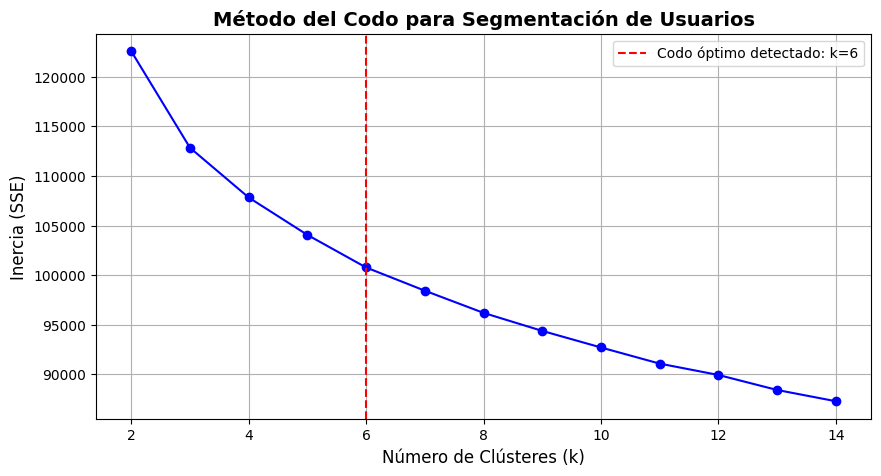

In [ ]:


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
import matplotlib.pyplot as plt

sse = []
silhouette_scores = []
rango_k = range(2, 15)

print("Calculando métricas... (esto puede tomar unos segundos con 7500 registros)")

for k in rango_k:
    # Crear el modelo con k-clusters
    kmeans_eval = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)

    # Ajustar el modelo a nuestros datos numéricos escalados
    kmeans_eval.fit(X_scaled_df)

    # Obtener las etiquetas
    labels = kmeans_eval.labels_

    # Obtener el valor de la función objetivo (Inercia/SSE)
    sse.append(kmeans_eval.inertia_)

    # Obtener la puntuación de silueta
    silhouette_scores.append(silhouette_score(X_scaled_df, labels))

# Clase que sirve para calcular el codo de forma automática
kl = KneeLocator(rango_k, sse, curve="convex", direction="decreasing")
print(f" ¡Cálculo completado! El codo matemático óptimo está en k = {kl.elbow}")

# --- Generación del Gráfico para visualizar el Codo ---
plt.figure(figsize=(10, 5))
plt.plot(rango_k, sse, marker='o', linestyle='-', color='b')
plt.axvline(x=kl.elbow, color='r', linestyle='--', label=f'Codo óptimo detectado: k={kl.elbow}')
plt.xlabel('Número de Clústeres (k)', fontsize=12)
plt.ylabel('Inercia (SSE)', fontsize=12)
plt.title('Método del Codo para Segmentación de Usuarios', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()

# GRÁFICO COMBINADO: CODO (INERCIA) Y SILUETA CON DOBLE EJE


El codo matemático detectado está en k = 6


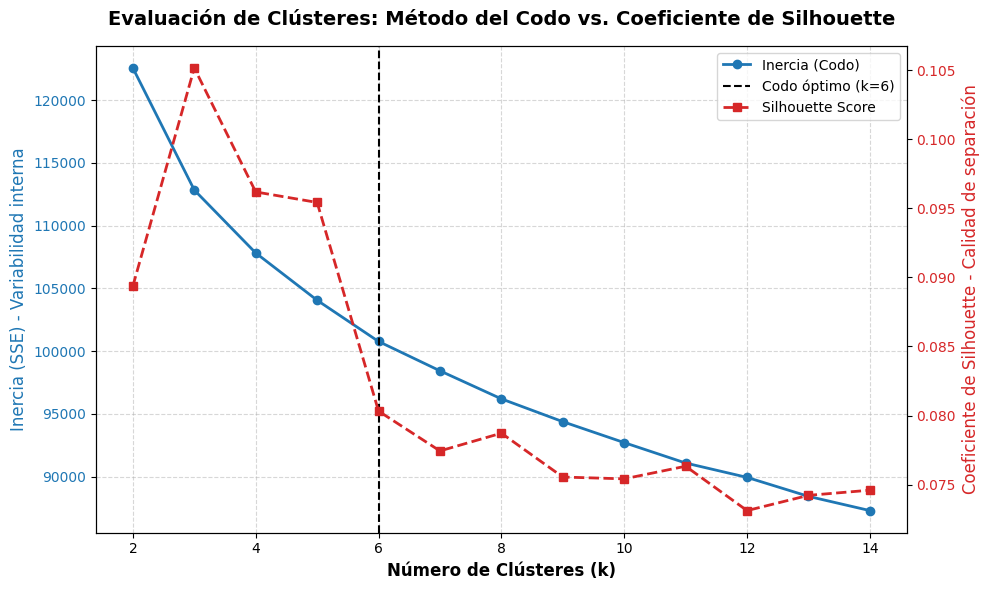

In [ ]:


# Detectamos el codo de forma automática (si no lo habías corrido en la celda anterior)
from kneed import KneeLocator
kl = KneeLocator(rango_k, sse, curve="convex", direction="decreasing")
print("El codo matemático detectado está en k =", kl.elbow)

# Graficamos ambos métodos para tomar la decisión
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Eje izquierdo para el Codo (Inercia / SSE) ---
color_inercia = 'tab:blue'
ax1.set_xlabel('Número de Clústeres (k)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Inercia (SSE) - Variabilidad interna', color=color_inercia, fontsize=12)
ax1.plot(rango_k, sse, marker='o', color=color_inercia, linewidth=2, label='Inercia (Codo)')

# Marcamos la línea del codo detectado
if kl.elbow:
    ax1.axvline(x=kl.elbow, color='black', linestyle='--', label=f'Codo óptimo (k={kl.elbow})')

ax1.tick_params(axis='y', labelcolor=color_inercia)
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Eje derecho para la Silueta ---
# ax1.twinx() crea un segundo eje Y que comparte el mismo eje X
ax2 = ax1.twinx()
color_silueta = 'tab:red'
ax2.set_ylabel('Coeficiente de Silhouette - Calidad de separación', color=color_silueta, fontsize=12)
ax2.plot(rango_k, silhouette_scores, marker='s', color=color_silueta, linewidth=2, linestyle='--', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color_silueta)

# Título y ajustes finales
plt.title('Evaluación de Clústeres: Método del Codo vs. Coeficiente de Silhouette', fontsize=14, fontweight='bold', pad=15)

# Para que aparezcan las leyendas de ambos ejes juntas
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

fig.tight_layout()
plt.show()


# ENTRENAMIENTO FINAL Y CARACTERIZACIÓN DE LOS GRUPOS DE PERFILES



In [ ]:

# 1. Instanciamos el modelo con el 'k' óptimo que detectó el codo automáticamente
k_optimo = kl.elbow
modelo_final = KMeans(n_clusters=k_optimo, init='k-means++', max_iter=300, n_init=10, random_state=42)

# 2. El modelo aprende la estructura de los datos numéricos (usamos los datos escalados)
modelo_final.fit(X_scaled_df)

# 3. Asignamos cada usuario a un clúster usando el método predict
# Lo guardamos en el DataFrame ORIGINAL para poder interpretar los datos reales (horas, cantidad)
df['cluster'] = modelo_final.predict(X_scaled_df)

# 4. Extracción de resultados: ¿Cuántos usuarios quedaron en cada grupo?
print("--- Cantidad de usuarios asignados por clúster ---")
print(df['cluster'].value_counts().sort_index())
print("\n" + "="*50 + "\n")

# 5. Análisis de "Tópicos" (En nuestro caso: Perfiles de Comportamiento)
# Calculamos el promedio de cada variable por clúster
columnas_analisis = [
    'age', 'daily_screen_time_hours', 'social_media_hours',
    'gaming_hours', 'work_study_hours', 'sleep_hours',
    'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time'
]

resumen_perfiles = df.groupby('cluster')[columnas_analisis].mean().round(2)

print("--- Perfiles detectados (Promedio de variables por Clúster) ---")
for i in range(k_optimo):
    print(f"\nCLÚSTER {i}:")

    # Extraemos y mostramos los valores promedio del clúster actual
    perfil = resumen_perfiles.loc[i]
    for variable, valor in perfil.items():
        print(f"  - {variable}: {valor}")

    # Extraemos muestras reales para validar el clúster (tomamos 3 user_id de ejemplo)
    ejemplos = df[df['cluster'] == i]['user_id'].head(3).tolist()
    print(f"   Usuarios de ejemplo: {ejemplos}")

--- Cantidad de usuarios asignados por clúster ---
cluster
0    1163
1    1220
2    1189
3    1345
4    1209
5    1374
Name: count, dtype: int64


--- Perfiles detectados (Promedio de variables por Clúster) ---

CLÚSTER 0:
  - age: 26.54
  - daily_screen_time_hours: 7.16
  - social_media_hours: 5.0
  - gaming_hours: 2.35
  - work_study_hours: 3.21
  - sleep_hours: 6.79
  - notifications_per_day: 132.87
  - app_opens_per_day: 97.13
  - weekend_screen_time: 8.87
   Usuarios de ejemplo: ['U00005', 'U00007', 'U00024']

CLÚSTER 1:
  - age: 26.7
  - daily_screen_time_hours: 5.16
  - social_media_hours: 2.36
  - gaming_hours: 1.83
  - work_study_hours: 3.32
  - sleep_hours: 6.67
  - notifications_per_day: 82.26
  - app_opens_per_day: 76.31
  - weekend_screen_time: 6.89
   Usuarios de ejemplo: ['U00002', 'U00003', 'U00014']

CLÚSTER 2:
  - age: 26.41
  - daily_screen_time_hours: 5.21
  - social_media_hours: 2.33
  - gaming_hours: 2.03
  - work_study_hours: 3.13
  - sleep_hours: 6.63
  - notifi

# **Visualización de los Clústeres y sus Centroides (PCA)**

Los centroides representan el "usuario promedio" de cada clúster. Se obtienen calculando el punto central de todas las coordenadas de los datos que pertenecen a ese grupo.

Para poder visualizar nuestros datos (que tienen múltiples dimensiones/variables) en un gráfico 2D, utilizamos **PCA (Análisis de Componentes Principales)**, lo que nos permite proyectar los perfiles de comportamiento de los usuarios en un plano cartesiano.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


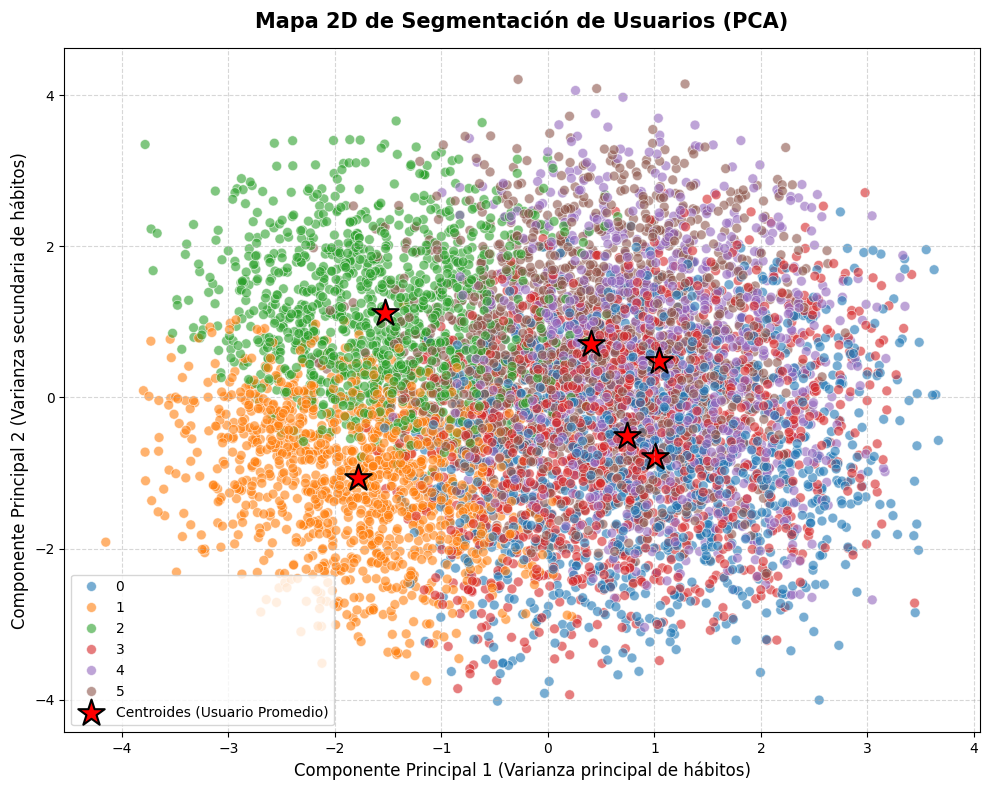

In [ ]:

# VISUALIZACIÓN DE CLÚSTERES Y CENTROIDES CON PCA (REDUCCIÓN DE DIMENSIONES)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reducimos los datos originales escalados a 2 dimensiones para el mapa
pca = PCA(n_components=2)
# Usamos directamente nuestro DataFrame escalado en lugar de la matriz TF-IDF
datos_2d = pca.fit_transform(X_scaled_df)

# 2. Proyectamos las coordenadas de los centroides al mismo espacio 2D
# Usamos el modelo_final que entrenamos en el paso anterior
centroides_2d = pca.transform(modelo_final.cluster_centers_)

# 3. Configuramos y creamos el gráfico
plt.figure(figsize=(10, 8))

# Graficamos cada usuario (antes "noticia")
sns.scatterplot(
    x=datos_2d[:, 0],
    y=datos_2d[:, 1],
    hue=modelo_final.labels_,
    palette='tab10',
    alpha=0.6,
    s=50
)

# Destacamos los centroides en color rojo con una ESTRELLA gigante
plt.scatter(
    centroides_2d[:, 0],
    centroides_2d[:, 1],
    c='red',
    marker='*',
    s=400,
    label='Centroides (Usuario Promedio)',
    edgecolors='black',
    linewidths=1.5
)

# Agregamos título y etiquetas a los ejes
plt.title('Mapa 2D de Segmentación de Usuarios (PCA)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Componente Principal 1 (Varianza principal de hábitos)', fontsize=12)
plt.ylabel('Componente Principal 2 (Varianza secundaria de hábitos)', fontsize=12)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Métricas de Evaluación por Modelo

In [ ]:
from sklearn.metrics import classification_report, silhouette_score

print("=== MÉTRICAS DEL MODELO DE CLASIFICACIÓN (NAIVE BAYES) ===")
# CORRECCIÓN: Cambiar y_pred_test por y_pred
print(classification_report(y_test, y_pred, target_names=['No Adicto (0)', 'Adicto (1)']))

print("\n=== MÉTRICAS DEL MODELO DE CLUSTERING (K-MEANS) ===")
silueta = silhouette_score(X_scaled_df, modelo_final.labels_)
print(f"Inercia Final (SSE - Variabilidad interna) : {modelo_final.inertia_:.2f}")
print(f"Coeficiente de Silhouette (Separación)     : {silueta:.4f}")

if silueta > 0.3:
    print("-> Interpretación: Los perfiles de usuarios están bien definidos y separados.")
else:
    print("-> Interpretación: Existe cierto grado de solapamiento entre los hábitos de los grupos.")

=== MÉTRICAS DEL MODELO DE CLASIFICACIÓN (NAIVE BAYES) ===
               precision    recall  f1-score   support

No Adicto (0)       1.00      1.00      1.00       438
   Adicto (1)       1.00      1.00      1.00      1062

     accuracy                           1.00      1500
    macro avg       1.00      1.00      1.00      1500
 weighted avg       1.00      1.00      1.00      1500


=== MÉTRICAS DEL MODELO DE CLUSTERING (K-MEANS) ===
Inercia Final (SSE - Variabilidad interna) : 100775.20
Coeficiente de Silhouette (Separación)     : 0.0803
-> Interpretación: Existe cierto grado de solapamiento entre los hábitos de los grupos.


In [ ]:
# EXPORTAR RESULTADOS PARA POWER BI
import pandas as pd

# Guardamos el archivo CSV sin el índice para que quede más limpio
nombre_archivo_bi = 'resultados_smartphones_powerbi.csv'
df.to_csv(nombre_archivo_bi, index=False)

print(f"¡Archivo '{nombre_archivo_bi}' exportado con éxito!")
print("Descárgalo desde la carpeta de Colab y cárgalo en Power BI para armar tus gráficos (ej. % de usuarios por clúster).")

¡Archivo 'resultados_smartphones_powerbi.csv' exportado con éxito!
Descárgalo desde la carpeta de Colab y cárgalo en Power BI para armar tus gráficos (ej. % de usuarios por clúster).


https://datastudio.google.com/s/qKkH0ryboQs
Este es para el link directo para el Looker Studio